#  Decoding Market Signals
## Predicting Stock Returns with LightGBM

In this notebook, we build a machine learning pipeline to predict future stock returns (`return_pct`) using company financial and market-related features. The workflow includes exploratory data analysis (EDA), data preprocessing, missing value handling, target distribution analysis, model training with LightGBM, performance evaluation, and generation of the final Kaggle submission.


### Workflow

- Loaded and inspected the datasets.
- Performed exploratory data analysis.
- Identified and handled missing values.
- Removed non-informative identifier columns.
- Built a preprocessing pipeline with median imputation.
- Trained a baseline LightGBM model.
- Evaluated performance using cross-validation.
- Analyzed the target distribution.
- Reduced extreme outliers through target clipping.
- Retrained the model with the transformed target.
- Generated predictions and created the final Kaggle submission file.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , KFold , cross_val_score , RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer


import warnings
warnings.filterwarnings("ignore")

##  Loading the Dataset

The training and test datasets are loaded into pandas DataFrames. The training dataset contains the target variable (`return_pct`), while the test dataset contains only the features used for prediction.

In [2]:
train = pd.read_csv('/kaggle/input/competitions/predict-1-year-us-stock-returns-from-fundamentals/train.csv')
test = pd.read_csv('/kaggle/input/competitions/predict-1-year-us-stock-returns-from-fundamentals/test.csv')

print(f"Training Data Shape : {train.shape}")
print(f"Testing Data Shape : {test.shape}")

Training Data Shape : (23070, 39)
Testing Data Shape : (8520, 36)


#  Exploratory Data Analysis (EDA)

The first step is to understand the dataset by examining its structure, feature types, missing values, and overall quality. This helps identify preprocessing requirements before building any machine learning model.

##  Dataset Overview

We inspect the dimensions, data types, and non-null counts of each feature using `.info()` and `.shape()`. This provides an understanding of the available variables and highlights potential missing-value issues.

In [3]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23070 entries, 0 to 23069
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   23070 non-null  int64  
 1   ticker               23070 non-null  object 
 2   start_year           23070 non-null  int64  
 3   period_start         23070 non-null  object 
 4   period_end           23070 non-null  object 
 5   return_pct           23070 non-null  float64
 6   pe_ttm               20694 non-null  float64
 7   price_to_book        17537 non-null  float64
 8   price_to_sales       19357 non-null  float64
 9   growth_pe_ratio      15054 non-null  float64
 10  gross_margin         8660 non-null   float64
 11  operating_margin     19351 non-null  float64
 12  net_margin           20379 non-null  float64
 13  roa                  18387 non-null  float64
 14  roe                  18116 non-null  float64
 15  rote                 18611 non-null 

##  Missing Value Analysis

Missing values are computed for every feature to determine the extent of incomplete data. Since several financial variables contain a significant number of missing observations, an imputation strategy will be required before model training.

In [4]:
print(train.isnull().sum())

id                         0
ticker                     0
start_year                 0
period_start               0
period_end                 0
return_pct                 0
pe_ttm                  2376
price_to_book           5533
price_to_sales          3713
growth_pe_ratio         8016
gross_margin           14410
operating_margin        3719
net_margin              2691
roa                     4683
roe                     4954
rote                    4459
revenue_growth_3y       7050
revenue_growth_yoy      4543
revenue_ttm             2590
net_income_ttm          1229
income_before_tax       7985
eps_basic                654
eps_diluted              963
total_assets            2876
stockholders_equity     3031
current_assets          7048
current_liabilities     7062
long_term_debt          7636
goodwill                7030
inventory              11514
current_ratio           7394
quick_ratio             7394
debt_to_equity          8592
dividend_yield         16617
dividends_ttm 

## Train vs Test Comparison

The columns of the training and test datasets are compared to identify differences. The training dataset contains the target variable (`return_pct`) and additional date columns (`period_start` and `period_end`), which are absent from the test dataset.

In [5]:
print(f"Training columns : {train.columns}")

print(f"\nTesting columns : {test.columns}")

Training columns : Index(['id', 'ticker', 'start_year', 'period_start', 'period_end',
       'return_pct', 'pe_ttm', 'price_to_book', 'price_to_sales',
       'growth_pe_ratio', 'gross_margin', 'operating_margin', 'net_margin',
       'roa', 'roe', 'rote', 'revenue_growth_3y', 'revenue_growth_yoy',
       'revenue_ttm', 'net_income_ttm', 'income_before_tax', 'eps_basic',
       'eps_diluted', 'total_assets', 'stockholders_equity', 'current_assets',
       'current_liabilities', 'long_term_debt', 'goodwill', 'inventory',
       'current_ratio', 'quick_ratio', 'debt_to_equity', 'dividend_yield',
       'dividends_ttm', 'dividends_paid_ttm', 'shares_outstanding',
       'shares_diluted', 'sector_code'],
      dtype='object')

Testing columns : Index(['id', 'ticker', 'start_year', 'pe_ttm', 'price_to_book',
       'price_to_sales', 'growth_pe_ratio', 'gross_margin', 'operating_margin',
       'net_margin', 'roa', 'roe', 'rote', 'revenue_growth_3y',
       'revenue_growth_yoy', 'revenue_ttm

In [6]:
print("Train-only columns:", set(train.columns) - set(test.columns))
print("Test-only columns :", set(test.columns) - set(train.columns))

Train-only columns: {'return_pct', 'period_end', 'period_start'}
Test-only columns : set()


##  Duplicate Record Check

Duplicate rows are examined to ensure data quality. No duplicate observations are found, indicating that each record represents a unique sample.

In [7]:
train.duplicated().sum()

np.int64(0)

## Ticker Analysis

The `ticker` feature is explored to understand its consistency across the datasets. It is observed that the training dataset contains actual stock tickers, whereas the test dataset uses anonymized identifiers (e.g., `stock_0001`). Since the identifiers do not correspond between train and test, this feature is removed to avoid introducing misleading patterns into the model.

In [8]:
print(f"Train Ticker : {set(train['ticker'].unique())}")

print(f"\n\nTest Ticker : {set(test['ticker'].unique())}")

Train Ticker : {'BROS', 'CALX', 'SJM', 'XMTR', 'OC', 'FRHC', 'ANET', 'MIRM', 'SRCE', 'EVOH', 'MTD', 'PTC', 'CBSH', 'TPR', 'CPT', 'AOSL', 'LENZ', 'TW', 'ABCL', 'DCOM', 'BHF', 'REVG', 'STE', 'WMK', 'MAT', 'CB', 'EPC', 'CSX', 'SEB', 'ANGI', 'ALRM', 'MPLX', 'UMBF', 'GMRE', 'DASH', 'SYRE', 'INVH', 'EPAC', 'ADC', 'AWR', 'SEIC', 'CBOE', 'ZD', 'PRAA', 'WES', 'PMT', 'TDG', 'IVT', 'MBLY', 'DAN', 'MEG', 'HUM', 'KNTK', 'DXCM', 'UCTT', 'TSCO', 'ASPN', 'LMT', 'CLFD', 'SBSI', 'MTRN', 'GRPN', 'GE', 'HAYW', 'WLY', 'LBRDA', 'NOC', 'TRVI', 'WD', 'BRC', 'ET', 'SCI', 'FHB', 'LBRT', 'RCL', 'AVO', 'BCRX', 'EQIX', 'WEC', 'LNG', 'BLDR', 'MKC', 'LUV', 'NHC', 'CBRL', 'OII', 'CSL', 'WAT', 'NSA', 'NVDA', 'PPG', 'ACN', 'ENVA', 'PLTR', 'GTM', 'KMI', 'CTOS', 'AMPX', 'ABM', 'WYNN', 'AUR', 'ENTG', 'FTNT', 'IAU', 'VICI', 'RES', 'ACI', 'KRYS', 'ANVS', 'BK', 'HTLD', 'AAL', 'POST', 'HRL', 'COGT', 'RCUS', 'APTV', 'AAAU', 'DUOL', 'ES', 'IDYA', 'FBRT', 'GSG', 'COHR', 'C', 'HASI', 'ARWR', 'FUNI', 'AXP', 'FOUR', 'EXPO', 'YUM', 

In [9]:
train_tickers = set(train['ticker'].unique())
test_tickers = set(test['ticker'].unique())

print(f"\nNo. of Train Tickers : {len(train_tickers)} ,\nNo. of Test Tickers : {len(test_tickers)}")
print(f"No. of Common Tickers in train and test : {len(train_tickers & test_tickers)}")
print(f"Train-only tickers : {len(train_tickers - test_tickers)}")
print(f"Test-only tickers : {len(test_tickers - train_tickers)}")


No. of Train Tickers : 1734 ,
No. of Test Tickers : 2200
No. of Common Tickers in train and test : 0
Train-only tickers : 1734
Test-only tickers : 2200


## Target Analysis

Axes(0.125,0.11;0.775x0.77)


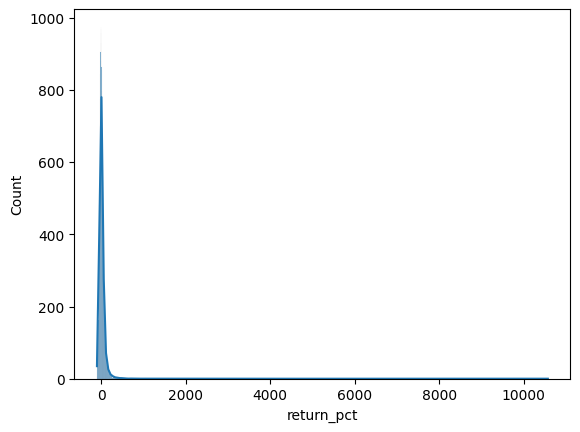

In [10]:
print(sns.histplot(train['return_pct'] , kde = True))

Axes(0.125,0.11;0.775x0.77)


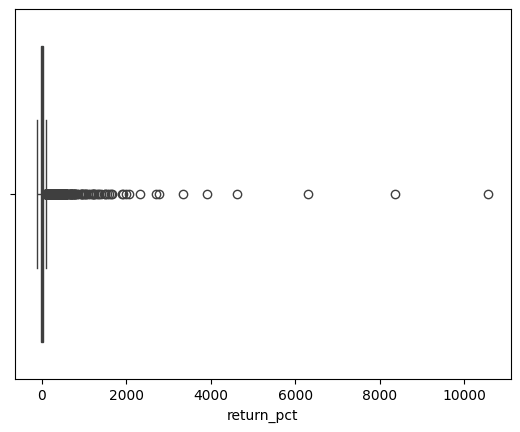

In [11]:
print(sns.boxplot(x = train['return_pct']))

#  Data Preprocessing

Before model training, the dataset is cleaned by removing non-informative features and handling missing values.

##  Feature Selection

Columns that are either identifiers or unavailable during inference are removed. These include:
- `id`
- `ticker`
- `period_start`
- `period_end`

The target variable (`return_pct`) is separated from the feature matrix.

In [12]:
train['return_pct'].describe()

count    23070.000000
mean        18.778736
std        138.650112
min        -99.170000
25%        -19.787500
50%          3.500000
75%         33.827500
max      10571.110000
Name: return_pct, dtype: float64

##  Missing Value Imputation

Since all remaining features are numerical, missing values are replaced using median imputation. The median is preferred because it is robust to outliers commonly present in financial datasets.

In [13]:
missing = train.isnull().mean() * 100
missing.sort_values(
    ascending = False
)

dividends_paid_ttm     93.216298
dividend_yield         72.028609
dividends_ttm          70.810577
gross_margin           62.462072
inventory              49.908973
debt_to_equity         37.243173
shares_outstanding     35.374946
growth_pe_ratio        34.746424
income_before_tax      34.612050
long_term_debt         33.099263
current_ratio          32.050282
quick_ratio            32.050282
current_liabilities    30.611183
revenue_growth_3y      30.559168
current_assets         30.550498
goodwill               30.472475
price_to_book          23.983528
roe                    21.473775
shares_diluted         21.183355
roa                    20.299090
revenue_growth_yoy     19.692241
rote                   19.328132
operating_margin       16.120503
price_to_sales         16.094495
stockholders_equity    13.138275
total_assets           12.466407
net_margin             11.664499
revenue_ttm            11.226701
pe_ttm                 10.299090
net_income_ttm          5.327265
eps_dilute

<Axes: >

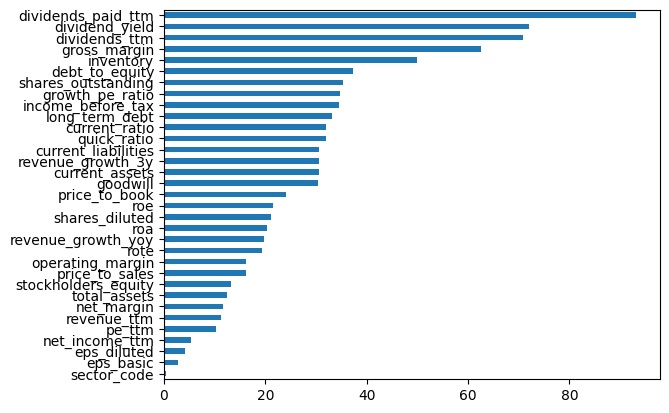

In [14]:
missing[missing > 0].sort_values().plot.barh()

In [15]:
print(f"No. of unique values in train ticker : {train['ticker'].nunique()}")
print(f"No. of unique values in train sector_code: {train['sector_code'].nunique()}")

No. of unique values in train ticker : 1734
No. of unique values in train sector_code: 11


In [16]:
train['sector_code'] = train['sector_code'].fillna(-1).astype(int)
test['sector_code'] = test['sector_code'].fillna(-1).astype(int)

In [17]:
target = train['return_pct']
train = train.drop(columns = ['id' , 'period_start' , 'period_end' , 'ticker' , 'return_pct'] , axis = 1)
id = test['id']
test = test.drop(columns = ['id' , 'ticker'] , axis = 1)

In [18]:
print(f"Shape of training data : {train.shape}")
print(f"Shape of testing data : {test.shape}")

Shape of training data : (23070, 34)
Shape of testing data : (8520, 34)


In [19]:
num_cols = train.select_dtypes(include = ['number']).columns.tolist()
print(f"Numerical Columns : {num_cols}")
print(f"\nNo. of numerical cols : {len(num_cols)}")

cat_cols = train.select_dtypes(exclude = ['number']).columns.tolist()
print(f"\nCatgorical Columns : {cat_cols}")
print(f"\nNo. of categorical cols : {len(cat_cols)}")

Numerical Columns : ['start_year', 'pe_ttm', 'price_to_book', 'price_to_sales', 'growth_pe_ratio', 'gross_margin', 'operating_margin', 'net_margin', 'roa', 'roe', 'rote', 'revenue_growth_3y', 'revenue_growth_yoy', 'revenue_ttm', 'net_income_ttm', 'income_before_tax', 'eps_basic', 'eps_diluted', 'total_assets', 'stockholders_equity', 'current_assets', 'current_liabilities', 'long_term_debt', 'goodwill', 'inventory', 'current_ratio', 'quick_ratio', 'debt_to_equity', 'dividend_yield', 'dividends_ttm', 'dividends_paid_ttm', 'shares_outstanding', 'shares_diluted', 'sector_code']

No. of numerical cols : 34

Catgorical Columns : []

No. of categorical cols : 0


In [20]:
X = train
y = target

In [21]:
X_train , X_val , y_train , y_val = train_test_split(X , y , test_size = 0.25 , random_state = 42)

In [22]:
preprocessor = Pipeline(
    steps = [
        ('imputer' , SimpleImputer(strategy = 'median'))
    ]
)

In [23]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)

# Baseline LightGBM Model

A baseline LightGBM regressor is trained using the processed features to establish an initial benchmark. Model performance is evaluated using Root Mean Squared Error (RMSE).

In [24]:
light_model = LGBMRegressor(
    random_state = 42,
    learning_rate = 0.1,
    n_estimators = 100,
    num_leaves = 31
)

light_model.fit(X_train_preprocessed , y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004303 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8116
[LightGBM] [Info] Number of data points in the train set: 17302, number of used features: 34
[LightGBM] [Info] Start training from score 18.535810


LGBMRegressor(random_state=42)

In [25]:
y_pred = light_model.predict(X_val_preprocessed)
y_pred

array([ 13.01428428, 270.99636013,  12.99477868, ..., -10.05797845,
         8.20268122, -13.25452144])

In [26]:
rmse = root_mean_squared_error(y_val , y_pred)
print(f"LightGBM default RMSE : {rmse}")

LightGBM default RMSE : 93.35654526113716


##  Cross-Validation

Five-fold cross-validation is performed to estimate the model's generalization performance. This provides a more reliable evaluation than relying on a single train-validation split.

In [27]:
cv_scores = cross_val_score(
    estimator = light_model,
    X = X_train_preprocessed,
    y = y_train,
    cv = 5,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1,
    verbose = 0
)
rmse_cv_scores = -cv_scores

print(f"RMSE CV Scores : {rmse_cv_scores}")

print(f"Mean RMSE Score after 5-Fold Cross Validation : {np.mean(rmse_cv_scores)}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RMSE CV Scores : [146.55677144  80.50429413 185.35824828  78.30440771 150.07053579]
Mean RMSE Score after 5-Fold Cross Validation : 128.15885147009163


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


#  Target Variable Analysis

The distribution of the target variable (`return_pct`) is analyzed. The target exhibits heavy positive skewness with several extreme outliers, which can negatively impact regression performance.

In [28]:
print(f"Skewness : {target.skew()}")
print(f"Extreme values returning greater than 500% : {(target > 500).sum()}")
print(f"Extreme values returning greater than 1000% : {(target > 1000).sum()}")

Skewness : 38.280836293128566
Extreme values returning greater than 500% : 86
Extreme values returning greater than 1000% : 34


In [29]:
for p in [ 0.01 , 0.05 , 0.10 , 0.25 , 0.50 , 0.75 , 0.90 , 0.95 , 0.99 , 0.995 , 0.999]:
    print(
        f"{int(p*1000)/10}% percentile of my data has : "
        f"{target.quantile(p):.2f} return %age or below"
    )

1.0% percentile of my data has : -80.20 return %age or below
5.0% percentile of my data has : -56.20 return %age or below
10.0% percentile of my data has : -41.15 return %age or below
25.0% percentile of my data has : -19.79 return %age or below
50.0% percentile of my data has : 3.50 return %age or below
75.0% percentile of my data has : 33.83 return %age or below
90.0% percentile of my data has : 76.52 return %age or below
95.0% percentile of my data has : 118.08 return %age or below
99.0% percentile of my data has : 299.17 return %age or below
99.5% percentile of my data has : 440.24 return %age or below
99.9% percentile of my data has : 1241.34 return %age or below


In [30]:
print("Above 100% return :", (target > 100).sum())
print("Above 500% return :", (target > 500).sum())
print("Above 1000%return : ", (target > 1000).sum())

Above 100% return : 1508
Above 500% return : 86
Above 1000%return :  34


##  Target Clipping

To reduce the influence of extreme outliers, the target variable is clipped between the 0.5th and 99.5th percentiles. This produces a more balanced target distribution while preserving the majority of observations.

In [31]:
lower = target.quantile(0.005)  # only 0.5 %
upper = target.quantile(0.995)  # 99.5 %

print(f"Upper limit : {upper}")
print(f"Lower limit : {lower}")

y_clipped = target.clip(
    upper = upper,
    lower = lower
)
print(y_clipped)

Upper limit : 440.2414999999985
Lower limit : -85.64240000000001
0        -5.62
1        36.93
2        13.81
3        48.18
4        44.15
         ...  
23065    -7.81
23066   -41.64
23067   -40.44
23068   -49.61
23069    17.42
Name: return_pct, Length: 23070, dtype: float64


#  Improved LightGBM Model

The LightGBM model is retrained using the clipped target values. Compared to the baseline model, the clipped target significantly improves prediction accuracy by reducing the effect of extreme values.

In [32]:
print(y.describe())

print("\n")

print(y_clipped.describe())

count    23070.000000
mean        18.778736
std        138.650112
min        -99.170000
25%        -19.787500
50%          3.500000
75%         33.827500
max      10571.110000
Name: return_pct, dtype: float64


count    23070.000000
mean        15.431825
std         64.659608
min        -85.642400
25%        -19.787500
50%          3.500000
75%         33.827500
max        440.241500
Name: return_pct, dtype: float64


In [33]:
print(f"Orignal Max Value : {target.max()}")
print(f"Clipped Max Value : {y_clipped.max()}")

Orignal Max Value : 10571.11
Clipped Max Value : 440.2414999999985


In [34]:
print(f"Orignal Skewness : {target.skew()}")
print(f"Clipped Skewness : {y_clipped.skew()}")

Orignal Skewness : 38.280836293128566
Clipped Skewness : 2.876372917029776


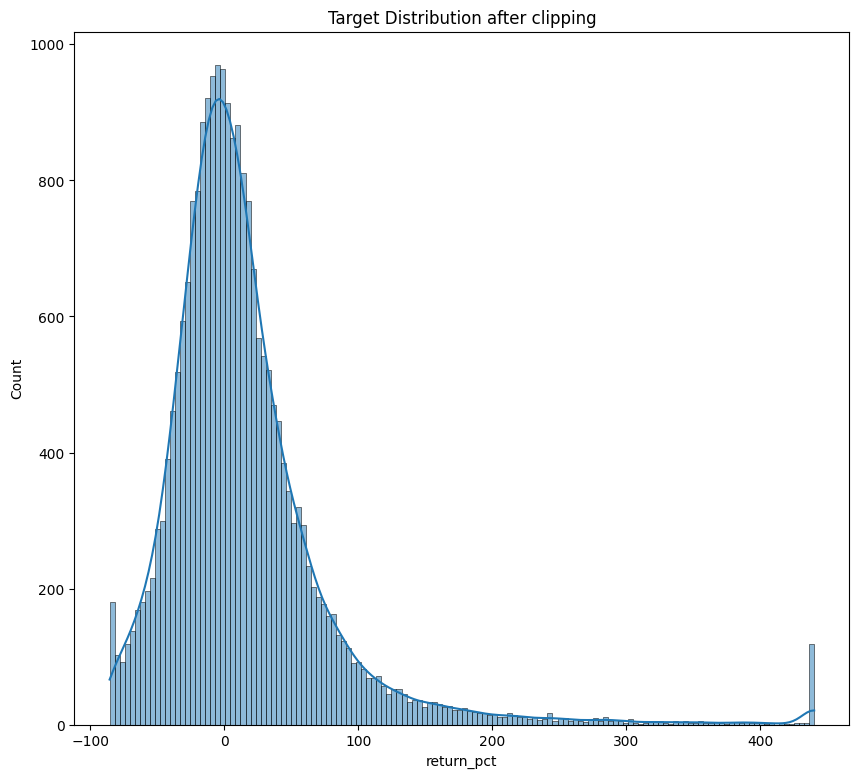

In [35]:
# seeing the histplot for my clipped target

plt.figure(figsize = (10 , 9))
sns.histplot(
    y_clipped , kde = True
)
plt.title("Target Distribution after clipping")
plt.show()

In [36]:
X = train
y_clipped = y_clipped

X_train2 , X_val2 , y_train2  ,y_val2 = train_test_split(
    X , y_clipped , test_size = 0.20 , random_state = 42
)


lgb_pipeline = Pipeline(
    steps = [
        ("null_values" , SimpleImputer(strategy = 'median')),
        ("lightgbm_model" , LGBMRegressor(
            objective = 'regression' , n_estimators = 500 , learning_rate = 0.05 , num_leaves = 31 , max_depth = -1 , random_state = 42
        ))
    ]
)

In [37]:
lgb_pipeline.fit( X_train2 , y_train2)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002270 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8129
[LightGBM] [Info] Number of data points in the train set: 18456, number of used features: 34
[LightGBM] [Info] Start training from score 15.363748


Pipeline(steps=[('null_values', SimpleImputer(strategy='median')),
                ('lightgbm_model',
                 LGBMRegressor(learning_rate=0.05, n_estimators=500,
                               objective='regression', random_state=42))])

In [38]:
y_pred_after_clipping = lgb_pipeline.predict(X_val2)
y_pred_after_clipping

array([ 21.34450489, 286.38045715,  12.17742641, ..., -14.8073866 ,
       -14.64671346, -11.44720051])

In [39]:
rmse2 = root_mean_squared_error(y_val2 , y_pred_after_clipping)

print(f"LightGBM RMSE after clipping with default params : {rmse2}")

LightGBM RMSE after clipping with default params : 48.74175866748049


#  Test Prediction and Submission

The trained model is applied to the test dataset to generate predictions. The predicted values are combined with the corresponding sample IDs and exported as a submission CSV file for Kaggle evaluation.

In [40]:
final_predictions = lgb_pipeline.predict(test)
submission = pd.DataFrame({
    "id" : id,
    "return_pct" : final_predictions
})

submission.to_csv('submissions.csv' , index = False)
submission

,id,return_pct
0,0,-5.266183
1,1,4.276977
2,2,1.052162
3,3,1.049369
4,4,16.816915
...,...,...
8515,8515,9.142827
8516,8516,-5.612403
8517,8517,-1.647767
8518,8518,22.222179


#  Conclusion

In this notebook, we developed a complete machine learning workflow for predicting stock returns.

### Key Steps Performed
- Conducted exploratory data analysis to understand the dataset.
- Examined missing values and dataset structure.
- Removed non-informative identifier columns.
- Applied median imputation for missing numerical values.
- Built a baseline LightGBM regression model.
- Evaluated performance using cross-validation.
- Analyzed the target distribution and identified extreme outliers.
- Applied target clipping to reduce skewness.
- Retrained the model, achieving a significantly lower validation RMSE.
- Generated predictions for the test dataset and exported the final submission file.

Overall, this notebook demonstrates how thoughtful preprocessing and target transformation can substantially improve regression performance without requiring a highly complex modeling pipeline.